In [362]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


df = pd.read_csv("investments_VCin.csv", encoding="latin1")  # or "ISO-8859-1"


In [363]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [364]:
total_info = df.memory_usage(deep=True)
total_info

Index                       132
permalink               3714344
name                    3023963
homepage_url            3449903
category_list           3604137
 market                 2955089
 funding_total_usd      2900846
status                  2821739
country_code            2465316
state_code              2155075
region                  2744135
city                    2708274
funding_rounds           395504
founded_at              2555361
founded_month           2505584
founded_quarter         2505584
founded_year             395504
first_funding_at        2855059
last_funding_at         2857302
seed                     395504
venture                  395504
equity_crowdfunding      395504
undisclosed              395504
convertible_note         395504
debt_financing           395504
angel                    395504
grant                    395504
private_equity           395504
post_ipo_equity          395504
post_ipo_debt            395504
secondary_market         395504
product_

In [365]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49438 entries, 0 to 49437
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  int64  
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [366]:
df.describe()

,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,...,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,1.628453e+05,...,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,7.579203,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,5.612088e+06,...,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,7.505000e+08,...,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [367]:
df.dtypes

permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds            int64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
last_funding_at          object
seed                      int64
venture                   int64
equity_crowdfunding       int64
undisclosed               int64
convertible_note          int64
debt_financing            int64
angel                     int64
grant                     int64
private_equity            int64
post_ipo_equity           int64
post_ipo_debt             int64
secondary_market          int64
product_crowdfunding      int64
round_A 

In [368]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns


In [369]:
df[numeric_cols].describe()
df[categorical_cols].describe()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,founded_at,founded_month,founded_quarter,first_funding_at,last_funding_at
count,49438,49437,45989,45477,45470,49438,48124,44165,30161,44165,43322,38554,38482,38482,49438,49438
unique,49436,49350,45850,16675,753,14617,3,115,61,1089,4188,3369,420,218,3914,3657
top,/organization/prysm,Roost,http://www.snapdeal.com,|Software|,Software,-,operating,USA,CA,SF Bay Area,San Francisco,1/1/2012,2012-01,2012-Q1,1/1/2012,1/1/2013
freq,2,4,2,3650,4620,8531,41829,28793,9917,6804,2615,2181,2327,2904,468,387


In [370]:
df_clean = df.copy()

In [371]:
df_clean.columns = df_clean.columns.str.strip().str.lower()

In [372]:
(df_clean['funding_total_usd']).unique()[:20]

array([' 17,50,000 ', ' 40,00,000 ', '40,000', ' 15,00,000 ', '60,000',
       ' 70,00,000 ', ' 49,12,393 ', ' 20,00,000 ', ' -   ', '41,250',
       ' 44,00,000 ', ' 20,50,000 ', ' 5,00,000 ', ' 25,35,000 ',
       ' 49,62,651 ', ' 40,59,079 ', ' 1,00,00,000 ', ' 30,00,000 ',
       ' 45,00,000 ', ' 4,20,000 '], dtype=object)

In [373]:
(df_clean['funding_total_usd'] == " -   ").sum()

np.int64(8531)

In [374]:
((df_clean['funding_total_usd'] == " -   ") & (df_clean["status"] == "operating")).sum()

np.int64(7403)

In [375]:
(df_clean['status'] == "operating").sum()

np.int64(41829)

In [376]:
(df_clean['status'] == "acquired").sum()

np.int64(3692)

In [377]:
(df_clean['status'] == "closed").sum()

np.int64(2603)

In [378]:
(df_clean['status']).unique()[:20]

array(['acquired', 'operating', nan, 'closed'], dtype=object)

In [379]:
df_clean["funding_total_usd"] = df_clean["funding_total_usd"].replace(" -   ",np.nan)
df_clean["funding_total_usd"] = df_clean["funding_total_usd"].astype(str).replace(" -   ",np.nan)
df_clean["funding_total_usd"] = df_clean["funding_total_usd"].replace(" -   ",np.nan)


In [380]:
df_clean['status'].isna().sum()

np.int64(1314)

In [381]:
df.isnull().sum().sort_values(ascending=False)

state_code              19277
founded_quarter         10956
founded_month           10956
founded_year            10956
founded_at              10884
city                     6116
region                   5273
country_code             5273
 market                  3968
category_list            3961
homepage_url             3449
status                   1314
name                        1
 funding_total_usd          0
permalink                   0
funding_rounds              0
first_funding_at            0
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B                     0
round_C   

In [382]:
df_clean.drop(columns=['state_code', 'founded_quarter', 'founded_month', 'homepage_url',"permalink"], inplace=True)

In [383]:
df_clean.head()

,name,category_list,market,funding_total_usd,status,country_code,region,city,funding_rounds,founded_at,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,#waywire,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,New York City,New York,1,6/1/2012,...,0,0,0,0,0,0,0,0,0,0
1,&TV Communications,|Games|,Games,"40,00,000",operating,USA,Los Angeles,Los Angeles,2,NaN,...,0,0,0,0,0,0,0,0,0,0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,"40,000",operating,EST,Tallinn,Tallinn,1,10/26/2012,...,0,0,0,0,0,0,0,0,0,0
3,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,London,London,1,4/1/2011,...,0,0,0,0,0,0,0,0,0,0
4,-R- Ranch and Mine,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,Dallas,Fort Worth,2,1/1/2014,...,0,0,0,0,0,0,0,0,0,0


In [384]:
df_clean.dropna(subset=["country_code","status","city","region","name"],inplace=True)

In [385]:
df_clean["founded_year"].head(10)

0     2012.0
1        NaN
2     2012.0
3     2011.0
4     2014.0
6        NaN
8     2010.0
9        NaN
10    2012.0
11       NaN
Name: founded_year, dtype: float64

In [386]:
df_clean.columns.tolist()

['name',
 'category_list',
 'market',
 'funding_total_usd',
 'status',
 'country_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_a',
 'round_b',
 'round_c',
 'round_d',
 'round_e',
 'round_f',
 'round_g',
 'round_h']

In [387]:
df_clean["founded_year"].fillna(df_clean["founded_year"].median(),inplace=True)
df_clean["market"].fillna("unknown",inplace=True)
df_clean["founded_at"].fillna("unknown",inplace=True)
df_clean["category_list"].fillna("unknown",inplace=True)

C:\Users\Pushkar\AppData\Local\Temp\ipykernel_23272\4112844183.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["founded_year"].fillna(df_clean["founded_year"].median(),inplace=True)
C:\Users\Pushkar\AppData\Local\Temp\ipykernel_23272\4112844183.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [388]:
df_clean.isna().sum()

name                    0
category_list           0
market                  0
funding_total_usd       0
status                  0
country_code            0
region                  0
city                    0
funding_rounds          0
founded_at              0
founded_year            0
first_funding_at        0
last_funding_at         0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
round_a                 0
round_b                 0
round_c                 0
round_d                 0
round_e                 0
round_f                 0
round_g                 0
round_h                 0
dtype: int64

In [389]:
df_clean["status"].value_counts()

status
operating    36663
acquired      3442
closed        2162
Name: count, dtype: int64

In [390]:
df_clean = pd.get_dummies(df_clean, columns=['market', 'country_code'], drop_first=True)

In [391]:
df_clean.select_dtypes(include='object').columns.tolist()

['name',
 'category_list',
 'funding_total_usd',
 'status',
 'region',
 'city',
 'founded_at',
 'first_funding_at',
 'last_funding_at']

In [392]:
df_clean.drop(columns=['category_list', 'name', 'founded_at'], inplace=True)

In [393]:
#df_clean = df_clean.astype(int)
df_clean['funding_total_usd'] = df_clean['funding_total_usd'].str.replace(',', '').str.strip().astype(float)

In [394]:
le = LabelEncoder()
df_clean['status'] = le.fit_transform(df_clean['status'])
print(le.classes_)

['acquired' 'closed' 'operating']


In [395]:
df_clean.drop(columns=["region","city"],inplace=True)
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [396]:
df_clean.select_dtypes(include='object').columns.tolist()

['first_funding_at', 'last_funding_at']

In [397]:
df_clean.drop(columns=["first_funding_at","last_funding_at"],inplace=True)

In [398]:
df_clean.select_dtypes(include='object').columns.tolist()


[]

In [399]:
df_clean.select_dtypes(include='object').columns.tolist()

[]

In [400]:
df_clean.dtypes.value_counts()

int64      868
float64      2
Name: count, dtype: int64

In [401]:
df_clean.tail()

,funding_total_usd,status,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,...,country_code_TWN,country_code_TZA,country_code_UGA,country_code_UKR,country_code_URY,country_code_USA,country_code_UZB,country_code_VNM,country_code_ZAF,country_code_ZWE
49432,2686600.0,2,1,2007.0,0,2686600,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49433,320000.0,2,1,2013.0,320000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49434,1587301.0,2,1,2009.0,0,1587301,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49435,97398.0,2,5,2012.0,71525,0,0,0,25873,0,...,0,0,0,0,0,0,0,0,0,0
49437,45000000.0,2,4,1999.0,0,28000000,0,0,0,17000000,...,0,0,0,0,0,1,0,0,0,0


In [402]:
X = df_clean.drop(columns=['status'])
y = df_clean['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(33813, 869) (8454, 869)


In [403]:
y.value_counts()

status
2    36663
0     3442
1     2162
Name: count, dtype: int64

In [404]:
print(le.classes_)

['acquired' 'closed' 'operating']


In [405]:
y_binary = (df_clean['status'] == 1).astype(int)
y_binary.value_counts()

status
0    40105
1     2162
Name: count, dtype: int64

In [406]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      8038
           1       0.15      0.06      0.08       416

    accuracy                           0.94      8454
   macro avg       0.55      0.52      0.52      8454
weighted avg       0.91      0.94      0.92      8454



In [407]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [408]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(y_train_sm.value_counts())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [409]:
print(X_train.isnull().sum().sum())  # how many NaNs total
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

5400
funding_total_usd    5400
dtype: int64


In [410]:
X_train["funding_total_usd"] = X_train["funding_total_usd"].fillna(0)
X_test["funding_total_usd"] = X_test["funding_total_usd"].fillna(0)

In [411]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(y_train_sm.value_counts())

status
0    32067
1    32067
Name: count, dtype: int64


In [413]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train_sm,y_train_sm)

y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      8038
           1       0.11      0.15      0.13       416

    accuracy                           0.90      8454
   macro avg       0.53      0.54      0.54      8454
weighted avg       0.91      0.90      0.90      8454



In [414]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 1.6/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 2.6/101.7 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 4.2/101.7 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 5.8/101.7 MB 6.0 MB/s eta 0:00:16
   -- ------------------------------------- 7.6/101.7 MB 6.6 MB/s eta 0:00:15
   --- ------------------------------------ 9.7/101.7 MB 7.1 MB/s eta 0:00:13
   ---- ----------------------------------- 11.5/101.7 MB 7.5 MB/s eta 0:00:13
   ----- ---------------------------------- 13.4/101.7 MB 7.6 MB/s eta 0:00:12
   ------ --------------------------------- 16.0/101.7 MB 8.1 MB/s eta 0:00:


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [415]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=40105/2162,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)  
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.72      0.82      8038
           1       0.09      0.56      0.16       416

    accuracy                           0.71      8454
   macro avg       0.53      0.64      0.49      8454
weighted avg       0.93      0.71      0.79      8454



In [418]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Tried threshold 0.3 to see if perfomance increase or not...
y_pred_tuned = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.97      0.72      0.82      8038
           1       0.09      0.56      0.16       416

    accuracy                           0.71      8454
   macro avg       0.53      0.64      0.49      8454
weighted avg       0.93      0.71      0.79      8454



In [419]:
import joblib
joblib.dump(xgb_model, 'startup_failure_detection.pkl')
print("Model has been saved")

Model has been saved


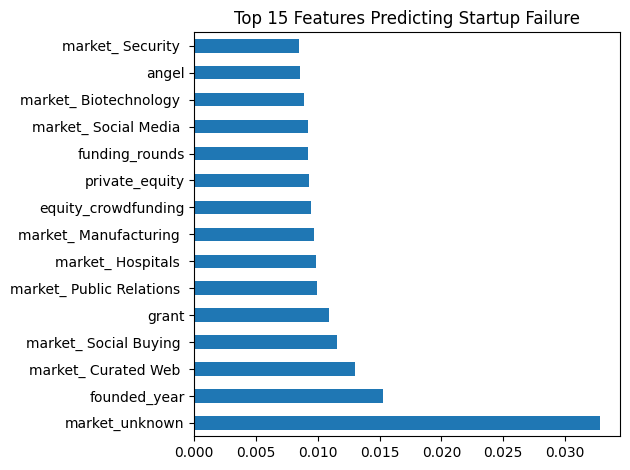

In [420]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(15).plot(kind='barh')
plt.title('Top 15 Features Predicting Startup Failure')
plt.tight_layout()
plt.show()

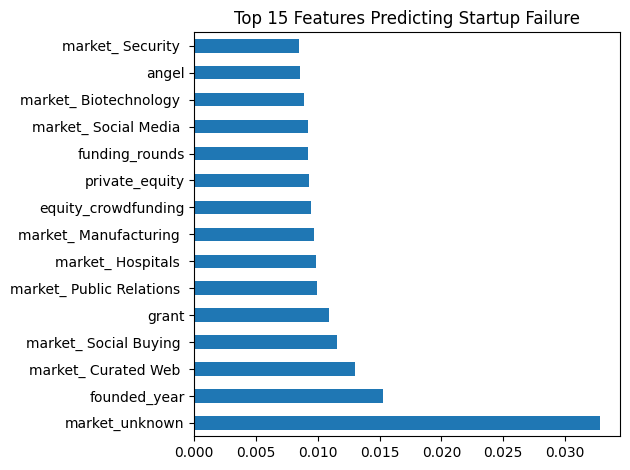

In [421]:
feat_imp.nlargest(15).plot(kind='barh')
plt.title('Top 15 Features Predicting Startup Failure')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)

In [422]:
import os
print(os.getcwd())

C:\Users\Pushkar
